The goal of this is to further annotate the E8.0 and E8.5 cardiac celltype done by the celltypist model trained with Robin+Pijuan data. 

1. We subset the cells to celltypist labeled cells CM, Exe Mesoderm, intermediate mesoderm, mesenchym, paraxial mesoderm, and pharyngeal mesoderm.

2. Regenerate umap and leiden clustering

3. Regenerate marker genes

4. Finding an appropriate leiden clustering and annotate the cluster with appropriate celltype (with Robin)


In [1]:
import scanpy as sc
import treedata as td
import matplotlib.pyplot as plt
from harmonypy import run_harmony

In [2]:
import sys
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')
from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom
from src.III_celltype_annotation.plot_celltype_annotation import (
    filter_marker_genes,
    get_marker_vmin_vmax,
    plot_marker_genes_feature,
    plot_markers_violin_comparison,
)
%load_ext autoreload
%autoreload 2


In [3]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/Celltypist_annotation/Robin_Pijuan/E8_5/Deeper_Cardiac_Annotation/"
output_path_plot = base_path+plot_dir+"/Celltypist_annotation/Robin_Pijuan/E8_5/Deeper_Cardiac_Annotation/"
tdata_file = base_path + data_dir + "/Processed_data/E8_5.h5td"

#### Loading data

In [4]:
tdata = td.read_h5td(tdata_file)

In [5]:
tdata

TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025_colors', 'Card

In [6]:
celltype_label = "Robin_Pijuan_annotation_E8_0_model_top1000_mv_label"

#### Loading subset instead

In [7]:
tdata_subset = td.read_h5td("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/temp/E8_5_cardiac_subset_deeper_annotation.h5td")

In [8]:
tdata_subset

TreeData object with n_obs × n_vars = 24213 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors',

Plotting umap with all celltypes on top

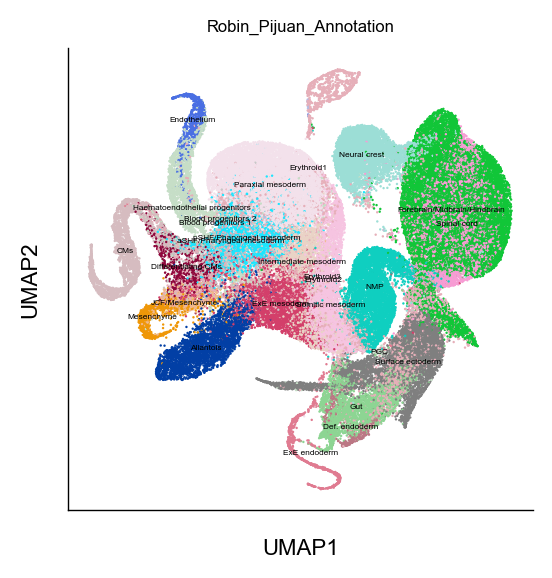

In [7]:
fig, ax = plt.subplots(figsize = (3,3), dpi = 200)
sc.pl.umap(tdata, size=3, ax=ax, color = celltype_label, title = "Robin_Pijuan_Annotation", show = False, legend_loc="on data", legend_fontsize=3)

plt.savefig(output_path_plot+"E8_5_Robin_Pijuan_Annotation_Cardiac_subset_label_on.png")

In [8]:
# List out the celltype name 
tdata.obs[celltype_label].unique().tolist()

['Forebrain/Midbrain/Hindbrain',
 'Erythroid3',
 'Spinal cord',
 'NMP',
 'Paraxial mesoderm',
 'Somitic mesoderm',
 'Intermediate mesoderm',
 'Haematoendothelial progenitors',
 'Neural crest',
 'ExE mesoderm',
 'Surface ectoderm',
 'Endothelium',
 'pSHF/Pharyngeal mesoderm',
 'Gut',
 'Def. endoderm',
 'Allantois',
 'CMs',
 'Differentiating CMs',
 'JCF/Mesenchyme',
 'aSHF/Pharyngeal mesoderm',
 'Mesenchyme',
 'Erythroid2',
 'ExE endoderm',
 'Erythroid1',
 'PGC',
 'Blood progenitors 2',
 'Blood progenitors 1']

In [ ]:
# set of celltypes to subset to

# For E8.0
# celltype_list = {'Intermediate mesoderm','Cardiomyocytes','Paraxial mesoderm','Pharyngeal mesoderm','Mesenchyme','ExE mesoderm',} 

# For E8.5
celltype_list = {"Differentiating CMs", "JCF/Mesenchyme", 'Intermediate mesoderm','CMs','Paraxial mesoderm','Pharyngeal mesoderm','Mesenchyme','ExE mesoderm', "aSHF/Pharyngeal mesoderm", "pSHF/Pharyngeal mesoderm" }

In [21]:
tdata_subset = tdata[tdata.obs[celltype_label].isin(celltype_list)]

In [22]:
tdata_subset

View of TreeData object with n_obs × n_vars = 6563 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Robin_celltypist_annotation', 'Robin_Pijuan_celltypist_annotation', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_0_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_colors', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l025_colors', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l05_colors', 'Robi

In [23]:
del tdata_subset.uns[celltype_label+"_colors"]

/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


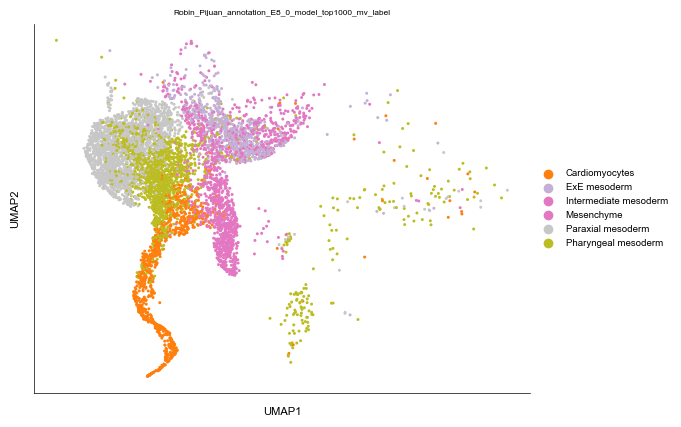

In [24]:
sc.pl.umap(tdata_subset, color = celltype_label)

#### Recalculating pca, umap, and leiden

In [25]:
tdata_subset.X.max()

np.float32(6084.0)

In [26]:
sc.experimental.pp.highly_variable_genes(tdata_subset, n_top_genes=2000)
sc.experimental.pp.normalize_pearson_residuals_pca(tdata_subset, use_highly_variable=True)

/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/scanpy/experimental/pp/_normalization.py:229: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  _, mask_var = _handle_mask_var(


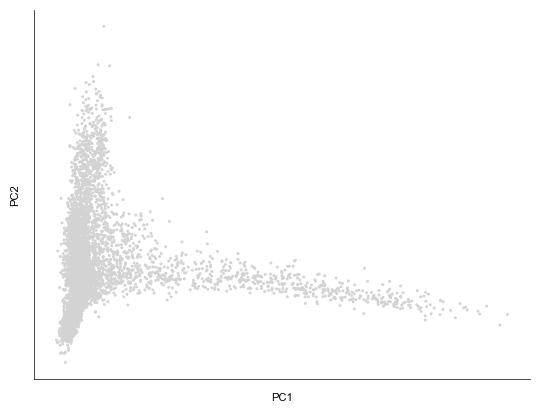

/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


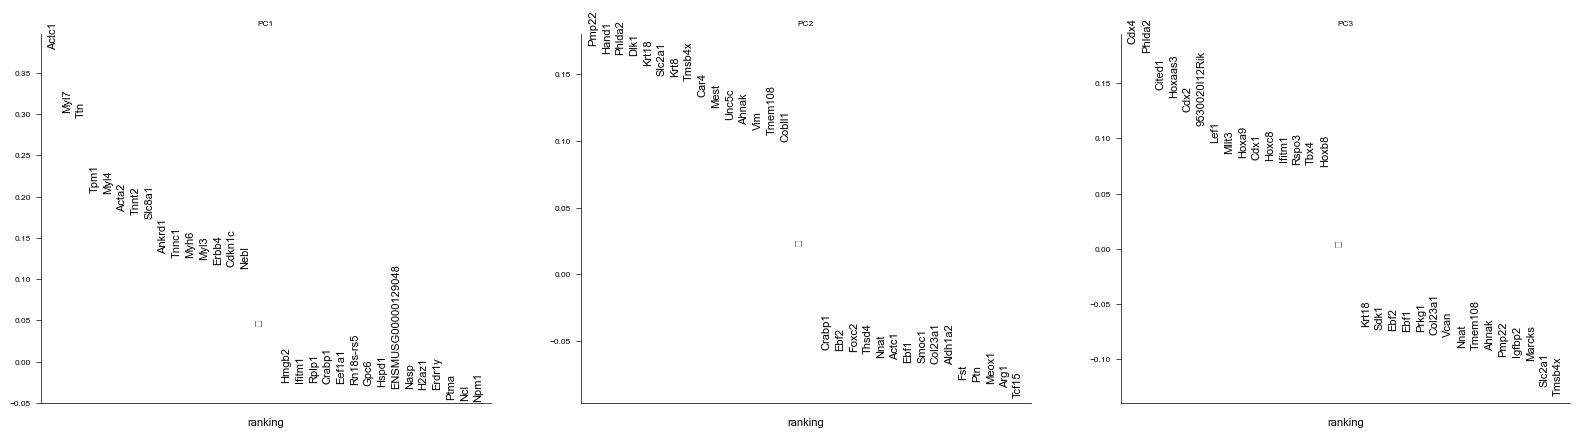

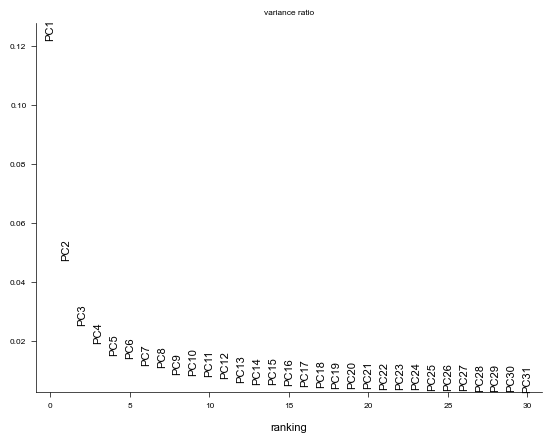

In [27]:
sc.pl.pca_overview(tdata_subset)

In [28]:
# Harmony integration on the PCA embedding
harmony_result = run_harmony(
    tdata_subset.obsm['X_pca'],
    tdata_subset.obs[['embryo']],
    vars_use=['embryo'],
    max_iter_harmony=20,
    theta=2.0,
    nclust=None,
    tau=0,
)
tdata_subset.obsm['X_pca_harmony'] = harmony_result.Z_corr

sc.pp.neighbors(tdata_subset, n_pcs=10, use_rep='X_pca_harmony')

2026-07-14 10:27:22,976 - harmonypy - INFO - Running Harmony
2026-07-14 10:27:22,976 - harmonypy - INFO -   Parameters:
2026-07-14 10:27:22,976 - harmonypy - INFO -     max_iter_harmony: 20
2026-07-14 10:27:22,977 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-14 10:27:22,977 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-14 10:27:22,978 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-14 10:27:22,978 - harmonypy - INFO -     nclust: 100
2026-07-14 10:27:22,978 - harmonypy - INFO -     block_size: 0.05
2026-07-14 10:27:22,979 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-14 10:27:22,979 - harmonypy - INFO -     theta: [2. 2. 2.]
2026-07-14 10:27:22,980 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-14 10:27:22,980 - harmonypy - INFO -     verbose: True
2026-07-14 10:27:22,981 - harmonypy - INFO -     random_state: 0
2026-07-14 10:27:22,981 - harmonypy - INFO -   Data: 50 PCs × 6563 cells
2026-07-14 10:27:22,981 - harmonypy - INFO -   B

In [29]:
sc.tl.umap(tdata_subset)

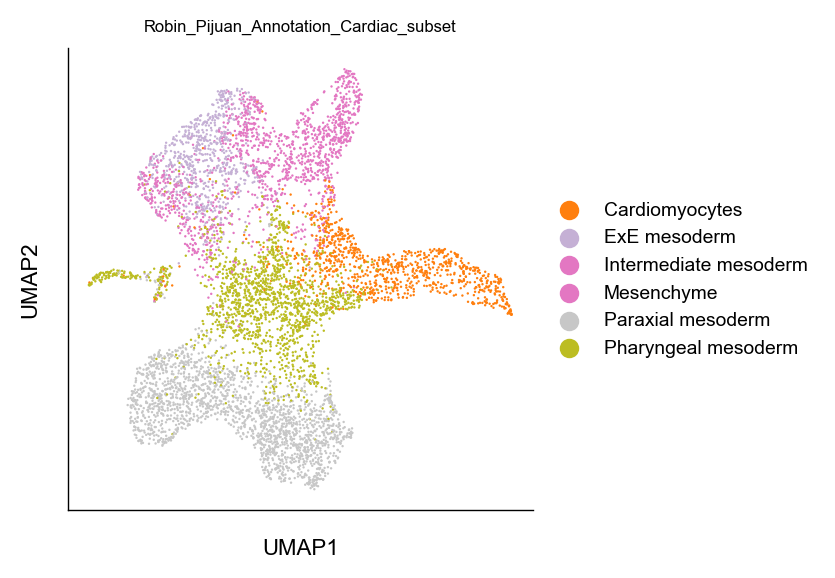

In [30]:
fig, ax = plt.subplots(figsize = (3,3), dpi = 200)
sc.pl.umap(tdata_subset, size=3, ax=ax, color = celltype_label, title = "Robin_Pijuan_Annotation_Cardiac_subset", show = False)
plt.savefig(output_path_plot+"E8_0_Robin_Pijuan_Annotation_Cardiac_subset.png", bbox_inches='tight')

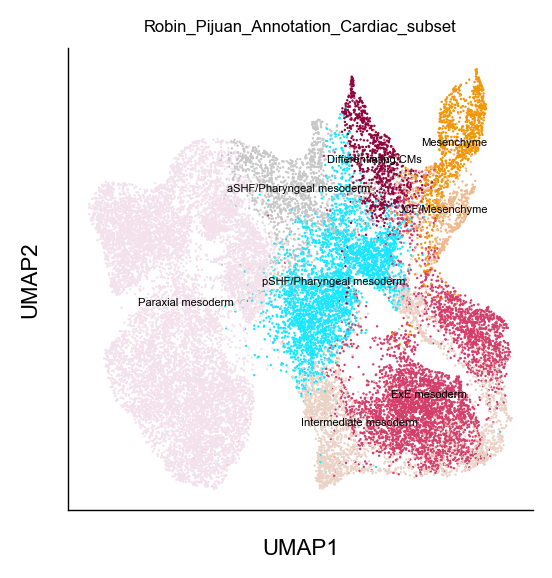

In [20]:
fig, ax = plt.subplots(figsize = (3,3), dpi = 200)
sc.pl.umap(tdata_subset, size=3, ax=ax, color = celltype_label, title = "Robin_Pijuan_Annotation_Cardiac_subset", show = False, legend_loc='on data', legend_fontsize=4)
plt.savefig(output_path_plot+"E8_5_Robin_Pijuan_Annotation_Cardiac_subset_legend_on.png")

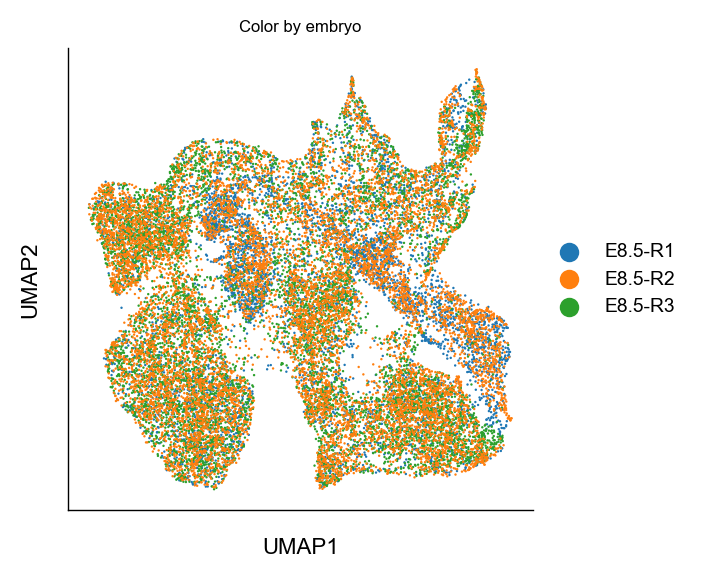

In [21]:
fig, ax = plt.subplots(figsize = (3,3), dpi = 200)
sc.pl.umap(tdata_subset, size=3, ax=ax, color = 'embryo', title = "Color by embryo", show = False)
plt.savefig(output_path_plot+"E8_5_cardiac_subset_colored_by_embryo.png", bbox_inches='tight')

harmony does not completely remove batch effect

#### Leiden Clustering

In [31]:
from src.II_integration_clustering.plot_integration_clustering import plot_clustering

In [32]:
res_list = [0.25, 0.5, 1.0, 2.0]

leiden_keys = []
for res in res_list:
    key = f"leiden_{res}"
    print(f"clustering for resolution {res}...")
    sc.tl.leiden(
        tdata_subset, resolution=res,
        key_added=key,
        neighbors_key="neighbors",
        flavor="igraph",
        n_iterations=2,
        directed=False
    )
    leiden_keys.append(key)

# build filename-safe names without decimals for saving plots
# e.g. leiden_0.25 -> l025
leiden_names = [
    "l" + key.split("_")[1].replace(".", "")
    for key in leiden_keys
]
tdata_subset.uns["leiden_names"] = leiden_names

plot_clustering(tdata_subset, leiden_keys, output_path_plot, legend_loc="on data", umap_coords_obsm = "X_umap")

clustering for resolution 0.25...
clustering for resolution 0.5...
clustering for resolution 1.0...
clustering for resolution 2.0...


#### Generate the same marker genes

In [24]:
grouped_markers = {
    "Primitive_streak": ["Nanog", "Eomes", "T"],
    "Nascent_mesoderm": ["Mesp2", "Lefty2", "Tdgf1", "Mesp1"],
    "Mixed_mesoderm": ["Phlda2", "Msx1", "Msx2", "Ifitm1"],
    "Paraxial_Pharyngeal_mesoderm": ["Tcf15"],
    "ExE_mesoderm": ["Cdx1", "Cdx2", "Cdx4", "Bmp4"],
    "aSH_Pharyngeal_mesoderm": ["Isl1", "Fgf10", "Tbx1", 'Fgf8'],
    "pSHF_Pharyngeal_mesoderm": ["Osr1", "Aldh1a2", "Arg1"],
    "Mesenchyme": ["Igf2", "Krt8", "Krt18", "Pmp22", "Ahnak"],
    "JCF_Mesenchyme": ["Hand1", "Foxf1", "Mab21l2"],
    "Cardiomyocytes": ["Ttn", "Tnnt2", "Myl7", "Acta2"],
}

In [ ]:
tdata_subset.X = tdata_subset.layers["Norm_count"]
markers_filtered = filter_marker_genes(tdata, grouped_markers)
markers_vmin_vmax = get_marker_vmin_vmax(adata=tdata_subset, markers_filtered=markers_filtered)

 
plot_marker_genes_feature(
adata=tdata_subset, umap_coords_obsm="X_umap",
markers_filtered=markers_filtered,
output_path_plot=output_path_plot+"/",
markers_vmin_vmax=markers_vmin_vmax)

In [33]:
tdata_subset

TreeData object with n_obs × n_vars = 6563 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Robin_celltypist_annotation', 'Robin_Pijuan_celltypist_annotation', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_0_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_colors', 'Robin_Pijuan_annotation_E8_0_model_top1000_mv_label_mode_l025_colors

#### Saving subsetted adata

In [ ]:
# tdata_subset.write("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/temp/E8_0_cardiac_subset_deeper_annotation.h5td")

#### Label Heart celltype on dataset based on feature plot on leiden Clusters

In [10]:
tdata_subset

TreeData object with n_obs × n_vars = 24213 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors',

In [22]:
# E8_0_leiden_2_0_mapping = {
#     "25": "CM", 
#     "20": "CM", 
#     "28": "CM",
#     "10": "pSHF",
#     "19": "pSHF",
#     "11": "pSHF",
#     "30": "pSHF",
#     "12": "aSHF",
#     "13": "aSHF",
#     "24": "JCF",
#     "4": "Differentiating CM",
#     "21": "Differentiating CM",
#     "22": "Differentiating CM",
# }

E8_5_leiden_1_0_mapping = {
    "4": "Differentiating CM",
    "7": "Differentiating CM",
    "16": "Differentiating CM",
    "18": "JCF",
    "19": "JCF",
    "9": "aSHF",
    "15": "aSHF",
    "14": "pSHF",
    "5": "pSHF"
}

In [23]:
tdata_subset.obs["cardiac_labels"] = tdata_subset.obs["leiden_1.0"].map(E8_5_leiden_1_0_mapping).astype("category")

In [24]:
tdata_subset.obs["cardiac_labels"].unique()

[NaN, 'pSHF', 'aSHF', 'Differentiating CM', 'JCF']
Categories (4, object): ['Differentiating CM', 'JCF', 'aSHF', 'pSHF']

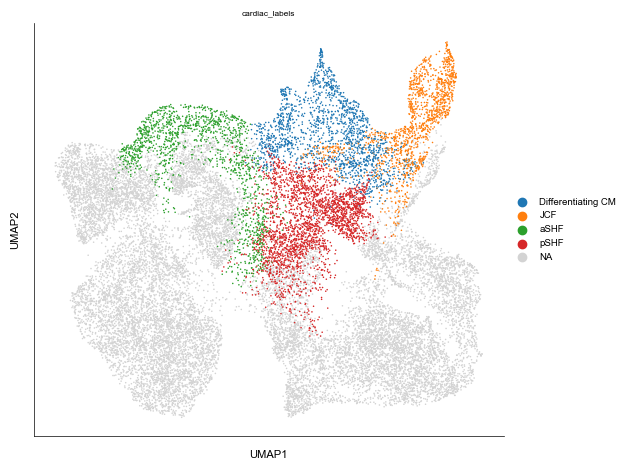

In [25]:
sc.pl.umap(tdata_subset, color = 'cardiac_labels', show=False)
plt.tight_layout()
plt.savefig(output_path_plot+"labeled_cardiac_celltype.png")

#### Adding label back to original dataset 

In [26]:
tdata.obs['cardiac_labels'] = tdata_subset.obs["cardiac_labels"]

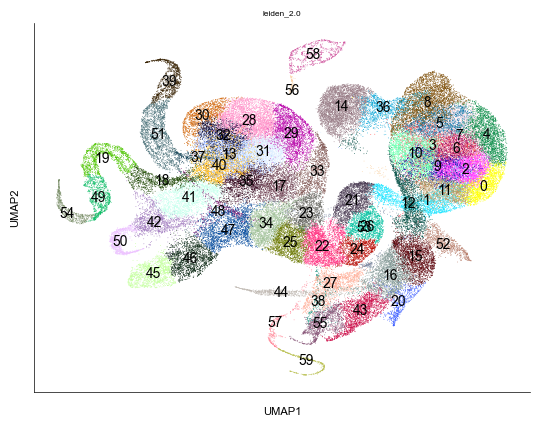

In [32]:
# Adding the original CM labeling 
sc.pl.umap(tdata, color = 'leiden_2.0', show=False, legend_loc= 'on data') # Taking 19, 49, 54 based on feature plot of CM genes
cardio_gene_map_leiden = {"19": "CMs",
                          "49": "CMs", 
                          "54": "CMs" 
                          }

tdata.obs['cardiac_labels'] = tdata.obs['leiden_2.0'].map(cardio_gene_map_leiden).combine_first(tdata_subset.obs["cardiac_labels"])

In [33]:
tdata.obs['cardiac_labels'].unique()

array([nan, 'pSHF', 'aSHF', 'Differentiating CM', 'CMs', 'JCF'],
      dtype=object)

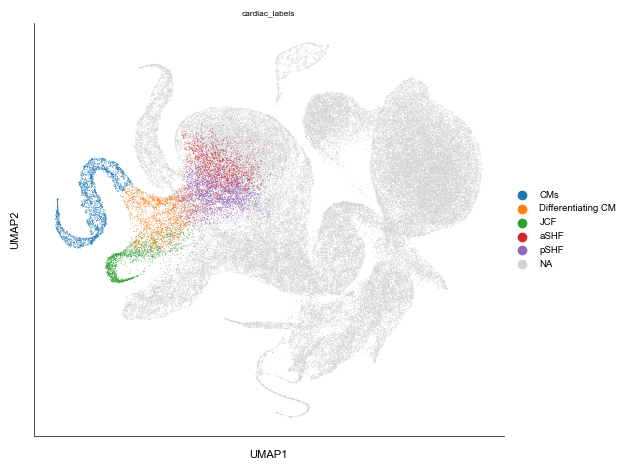

In [35]:
sc.pl.umap(tdata, color = 'cardiac_labels', show=False)
plt.tight_layout()
plt.savefig(output_path_plot+"labeled_cardiac_on_full_tdata.png")

In [36]:
tdata.write_h5td(tdata_file)